# Representing JAX Device Mesh Sharding with CuTe Layouts

JAX's `jax.make_mesh` creates a device mesh by reshaping physical devices into a logical grid.
When the physical device topology doesn't match a simple linear order, the resulting mesh
has a non-trivial device-ID mapping. We can represent this exactly using CuTe's `Swizzle` + `Layout`.

## The JAX setup

```python
mesh = jax.make_mesh((4, 2), ('a', 'b'))
y = jax.device_put(x, NamedSharding(mesh, P('a', 'b')))
jax.debug.visualize_array_sharding(y)
```

```
┌──────────┬──────────┐
│  TPU 0   │  TPU 1   │
├──────────┼──────────┤
│  TPU 2   │  TPU 3   │
├──────────┼──────────┤
│  TPU 6   │  TPU 7   │
├──────────┼──────────┤
│  TPU 4   │  TPU 5   │
└──────────┴──────────┘
```

Notice the device IDs aren't in simple row-major order: rows 2 and 3 are swapped (6,7 before 4,5).
This reflects the physical TPU interconnect topology.

## Step 1: Row-major baseline

A plain 4x2 row-major layout maps `(i,j) -> 2i + j`, giving device IDs 0,1,2,3,4,5,6,7 in order.

(4, 2) : (2, 1)


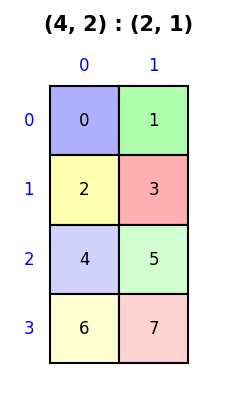

In [1]:
from tensor_layouts import Layout, Swizzle, compose
from tensor_layouts.viz import draw_layout

row_major = Layout((4, 2), (2, 1))
print(row_major)
draw_layout(row_major, colorize=True)

## Step 2: The topology permutation as a Swizzle

The physical device order is `[0, 1, 2, 3, 6, 7, 4, 5]` — for devices 4-7, bit 1 is flipped.
In binary:

| Position | Binary | Device | Binary | XOR |
|----------|--------|--------|--------|-----|
| 0 | 000 | 0 | 000 | — |
| 1 | 001 | 1 | 001 | — |
| 2 | 010 | 2 | 010 | — |
| 3 | 011 | 3 | 011 | — |
| 4 | **1**00 | 6 | **1**10 | bit 2 XORed into bit 1 |
| 5 | **1**01 | 7 | **1**11 | bit 2 XORed into bit 1 |
| 6 | **1**10 | 4 | **1**00 | bit 2 XORed into bit 1 |
| 7 | **1**11 | 5 | **1**01 | bit 2 XORed into bit 1 |

This is exactly `Swizzle(bits=1, base=1, shift=1)`: XOR 1 bit starting at position `base=1` with the bit at `base+shift=2`.

In [2]:
sw = Swizzle(1, 1, 1)
print("Swizzle permutation:")
for i in range(8):
    print(f"  {i} -> {sw(i)}")

Swizzle permutation:
  0 -> 0
  1 -> 1
  2 -> 2
  3 -> 3
  4 -> 6
  5 -> 7
  6 -> 4
  7 -> 5


## Step 3: Compose to get the mesh layout

Composing the swizzle with the row-major layout gives us the full device mesh mapping:

`mesh(i, j) = Swizzle(row_major(i, j))`

In [3]:
mesh_layout = compose(Swizzle(1, 1, 1), Layout((4, 2), (2, 1)))
print(mesh_layout)
print()

for i in range(4):
    row = [f"TPU {mesh_layout(i, j)}" for j in range(2)]
    print(f"  row {i}: {row}")

(Swizzle(1, 1, 1)) o ((4, 2) : (2, 1))

  row 0: ['TPU 0', 'TPU 1']
  row 1: ['TPU 2', 'TPU 3']
  row 2: ['TPU 6', 'TPU 7']
  row 3: ['TPU 4', 'TPU 5']


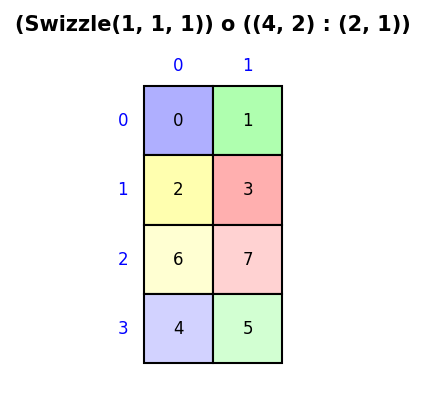

In [4]:
draw_layout(mesh_layout, colorize=True)

The visualization shows the same 4x2 grid with device IDs matching the JAX output:
TPUs 0,1 / 2,3 / 6,7 / 4,5 — the topology-aware ordering captured entirely
by a single `Swizzle` composed with a standard row-major layout.

## Step 4: Sharding an 8x4 array with contiguous local chunks

Now consider an 8×4 array sharded across this 4×2 mesh with `P('a', 'b')`.
Each device gets a 2×2 tile. We want the local chunks to be **contiguous** in memory,
since hopping between devices is expensive.

We build this in two steps:
1. `blocked_product(local_tile, device_mesh)` — tile the local 2×2 chunk across device positions
2. Compose `Swizzle(1, 3, 1)` on the result — the same XOR permutation, but shifted to operate on the device-ID bits (bits 2–4) of the full offset

In [5]:
from tensor_layouts import blocked_product

# Local tile: 2x2 column-major (contiguous 4 elements per device)
local_tile = Layout((2, 2), (1, 2))

# Device mesh: plain row-major (swizzle applied later at correct bit positions)
device_mesh = Layout((4, 2), (2, 1))

# blocked_product tiles the local chunk across device positions
blocked = blocked_product(local_tile, device_mesh)
print("Without swizzle:", blocked)

# Swizzle(1, 3, 1): same XOR as before, but shifted up by 2 bits
# because each device owns 4 elements (2 bits), so device ID starts at bit 2
full = compose(Swizzle(1, 3, 1), blocked)
print("With swizzle:   ", full)
print()

# Print the 8x4 grid with device assignments
for i in range(8):
    offsets = [f"{full(i, j):2d}" for j in range(4)]
    devices = [f"d{full(i, j) // 4}" for j in range(4)]
    print(f"  row {i}: offsets [{', '.join(offsets)}]  devices [{', '.join(devices)}]")

Without swizzle: ((2, 4), (2, 2)) : ((1, 8), (2, 4))
With swizzle:    (Swizzle(1, 3, 1)) o (((2, 4), (2, 2)) : ((1, 8), (2, 4)))

  row 0: offsets [ 0,  2,  4,  6]  devices [d0, d0, d1, d1]
  row 1: offsets [ 1,  3,  5,  7]  devices [d0, d0, d1, d1]
  row 2: offsets [ 8, 10, 12, 14]  devices [d2, d2, d3, d3]
  row 3: offsets [ 9, 11, 13, 15]  devices [d2, d2, d3, d3]
  row 4: offsets [24, 26, 28, 30]  devices [d6, d6, d7, d7]
  row 5: offsets [25, 27, 29, 31]  devices [d6, d6, d7, d7]
  row 6: offsets [16, 18, 20, 22]  devices [d4, d4, d5, d5]
  row 7: offsets [17, 19, 21, 23]  devices [d4, d4, d5, d5]


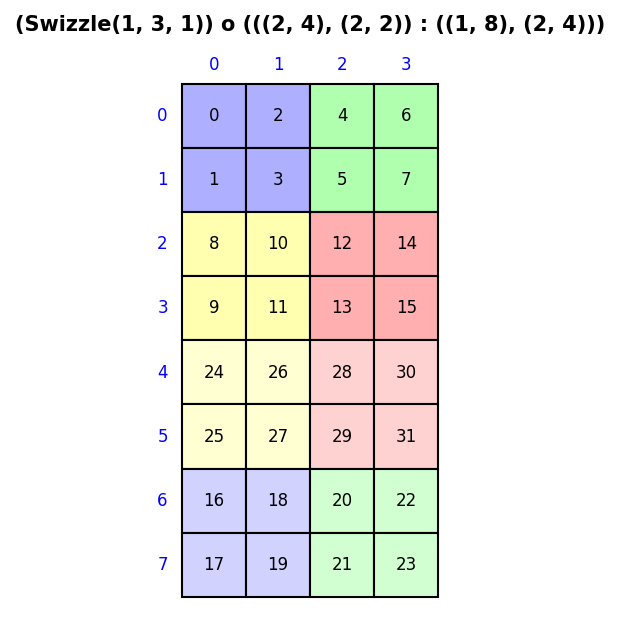

In [6]:
# Color by device ID: map each (i,j) to its device via the swizzled mesh
color_base = blocked_product(Layout((2, 2), (0, 0)), Layout((4, 2), (2, 1)))
color = compose(Swizzle(1, 1, 1), color_base)

draw_layout(full, color_layout=color, colorize=True, num_colors=8)

Each 2×2 block of same-colored cells is a contiguous chunk in memory (4 consecutive offsets).
The block-to-device assignment follows the swizzled mesh order: devices 0,1,2,3,6,7,4,5.

The key insight: `Swizzle(1, 1, 1)` and `Swizzle(1, 3, 1)` are the *same* XOR permutation —
the only difference is which bits it acts on. At the device level (3-bit IDs), it's `Swizzle(1, 1, 1)`.
At the element level (5-bit offsets with 2 local bits), it shifts up to `Swizzle(1, 3, 1)` so it
still targets the device-ID bits while leaving the local-offset bits untouched.